#  Hypothesis Testing Activity <hr style="border:2px solid #ff4fb0ff "><hr>

<b>Hazel Mae C. Jalandoni</b>
<br>Comp Eng Tech Student

In [1]:
# imports and packages
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [10]:
# load datasets
df = pd.read_csv(r"tips.csv",
                 delimiter=",")
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [11]:
# summary of dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [14]:
# summary of statistics
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


# 2-Sample t-Test

## Total Bill and Tips

In [16]:
"""
Summary of Statistics
"""
df[['total_bill','tip']].describe()

,total_bill,tip
count,244.000000,244.000000
mean,19.785943,2.998279
std,8.902412,1.383638
min,3.070000,1.000000
25%,13.347500,2.000000
50%,17.795000,2.900000
75%,24.127500,3.562500
max,50.810000,10.000000


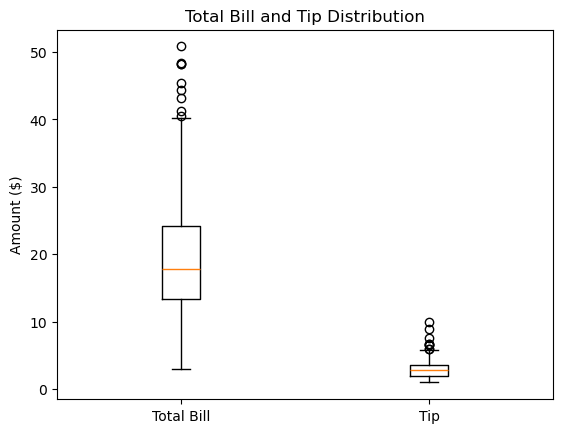

In [26]:
"""
Boxplot
----------------
"""
# check for outliers
plt.boxplot(df[['total_bill','tip']], tick_labels=['Total Bill','Tip'])
plt.title("Total Bill and Tip Distribution")
plt.ylabel('Amount ($)')
plt.show()

In [28]:
"""
Normality Test
------------------
"""
# shapiro-wilk normality test
print("\nTotal Bill:")
w_stat, p_value = stats.shapiro(df['total_bill'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")
    
print("\nTip:")
w_stat, p_value = stats.shapiro(df['tip'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")


Total Bill:
w_stat: 0.9197
P-value: 0.0000
Non-normal data

Tip:
w_stat: 0.8978
P-value: 0.0000
Non-normal data


In [30]:
"""
F-Test 
--------------------------------
Ho: var_totalbill = var_tip
Ha: var_totalbill != var_tip
"""

var_totalbill = df['total_bill'].var(ddof=1)
var_tip = df['tip'].var(ddof=1)

# F-statistic
if var_totalbill > var_tip:
    f_stat = var_totalbill/var_tip
else:
    f_stat = var_tip/var_totalbill

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_totalbill = df['total_bill'].count()-1
dof_tip = df['tip'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_totalbill, dof_tip)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 41.3971
p_value = 0.0000
unequal variances


In [35]:
"""
2 - Sample T-Test
----------------------------------------
Ho: Total Bill <= Tip
Ha: Total Bill > Tip
"""

t_stat, p_value = stats.ttest_ind(df['total_bill'],df['tip'],
                                  alternative='greater',
                                  equal_var=False)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("The average Total Bill is significantly higher than the average Tip.")
    # fail to reject null hypothesis
else:
    print("There is no significant difference between the average Total Bill and Tip.")

t_stat = 29.1068
p_value = 0.0000
The average Total Bill is significantly higher than the average Tip.


In [36]:
"""
Power of the Test
------------------
Ho: μtotalbill ≤ μtip
Ha: μtotalbill > μtip
"""
    
# cohen's d
totalbill_mean = df['total_bill'].mean()
tip_mean = df['tip'].mean()
totalbill_std = df['total_bill'].std(ddof=1)

d = abs((totalbill_mean - tip_mean)/totalbill_std)

print(f"Cohen's d: {d:.4f}")

# power of a test
power = TTestPower().power(
    effect_size = -d, # difference must be negative for alternative='smaller'
    nobs = df['total_bill'].count(),
    alpha = 0.05,
    alternative = "smaller"
)

print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 1.8857
Power of the test: 100.00%
